In [39]:
!python --version

Python 3.11.10


In [2]:
import importlib

import datamanip
from train_eval.evaluate import evaluate_ensamble, evaluate
from utils import load_best_model_based_on_match

import torch
from torch_geometric.loader import DataLoader
from filepath import *
from datamanip.datasetmanip.three_five_dataset import ThreeFiveDataset
from datamanip.plots import generate_matrix, visualize_samples_outside_of_radii

In [3]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [24]:
train_set = ThreeFiveDataset(root=dataset_path, match='ensemble', test_train_val="train")
test_set = ThreeFiveDataset(root=dataset_path, match='ensemble', test_train_val="test")
val_set = ThreeFiveDataset(root=dataset_path, match='ensemble', test_train_val="val")
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
test_loader = DataLoader(test_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32, shuffle=True)

In [25]:

matches = ["1-1", "2-1", "2-2", "3-1", "3-2", "3-3", "3-4"]
ensemble = {}
for match in matches:
    ensemble[match] = load_best_model_based_on_match(match)

In [26]:

for match, model in ensemble.items():
    model.eval()

In [27]:

# Function to collect predictions from base models
def get_meta_features(loader):
    meta_features, labels = [], []
    for data in loader:
        outputs = []
        for match, model in ensemble.items():
            with torch.no_grad():

                prob = torch.sigmoid(model(data)).cpu().numpy()
                outputs.append(prob)
       #         print(prob)
        meta_features.append(np.hstack(outputs))
        labels.append(data.y.cpu().numpy())
        #print(labels)
    return np.vstack(meta_features), np.hstack(labels)

In [28]:
'''
def get_meta_features(loader):
    meta_features = []
    true_labels = []
    for data in loader:
        batch_size = data.num_graphs
        batch_features = [[] for _ in range(batch_size)]
        for model in ensemble.values():
            with torch.no_grad():
                output = model(data)
                probs = torch.sigmoid(output).squeeze().cpu().numpy()
                if probs.ndim == 0:
                    probs = np.expand_dims(probs, axis=0)
                preds = (probs >= 0.5).astype(int)
                confidences = np.abs(probs - 0.5)
                for i in range(batch_size):
                    batch_features[i].append([probs[i], preds[i], confidences[i]])
        meta_features.extend(batch_features)
        true_labels.extend(data.y.cpu().numpy())
    return np.array(meta_features), np.array(true_labels)
'''

'\ndef get_meta_features(loader):\n    meta_features = []\n    true_labels = []\n    for data in loader:\n        batch_size = data.num_graphs\n        batch_features = [[] for _ in range(batch_size)]\n        for model in ensemble.values():\n            with torch.no_grad():\n                output = model(data)\n                probs = torch.sigmoid(output).squeeze().cpu().numpy()\n                if probs.ndim == 0:\n                    probs = np.expand_dims(probs, axis=0)\n                preds = (probs >= 0.5).astype(int)\n                confidences = np.abs(probs - 0.5)\n                for i in range(batch_size):\n                    batch_features[i].append([probs[i], preds[i], confidences[i]])\n        meta_features.extend(batch_features)\n        true_labels.extend(data.y.cpu().numpy())\n    return np.array(meta_features), np.array(true_labels)\n'

In [29]:
meta_X_train, meta_y_train = get_meta_features(train_loader)

In [30]:
'''
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
# Define and train the meta-learner
meta_learner = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000))
])

meta_learner.fit(meta_X_train, meta_y_train)
'''

"\nfrom sklearn.pipeline import Pipeline\nfrom sklearn.preprocessing import StandardScaler\n# Define and train the meta-learner\nmeta_learner = Pipeline([\n    ('scaler', StandardScaler()),\n    ('clf', LogisticRegression(max_iter=1000))\n])\n\nmeta_learner.fit(meta_X_train, meta_y_train)\n"

In [15]:

from sklearn.ensemble import RandomForestClassifier

In [31]:
meta_learner = RandomForestClassifier(n_estimators=100, random_state=42)
meta_learner.fit(meta_X_train, meta_y_train)

RandomForestClassifier(random_state=42)

In [36]:
meta_X_test, meta_y_test = get_meta_features(test_loader)

In [37]:
test_preds = meta_learner.predict(meta_X_test)

In [43]:
accuracy = accuracy_score(meta_y_test, test_preds)
print(f"Test Accuracy: {accuracy}")

Test Accuracy: 0.9207601497264613


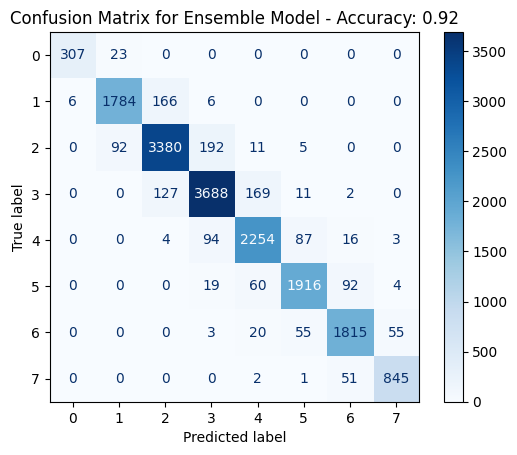

NameError: name 'outside_1' is not defined

In [44]:
generate_matrix(meta_y_test, test_preds, accuracy, "Ensemble Model")